# **[IA04] Miss Around and Find Out: the Impact of Missing Data Types**

#### Francisco Silva Cunha Campos - FEUP/FCUP, M.IA

## **Introduction**

For this notebook, we will work with one medium-sized dataset with no missing values: [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction).

The objective is to analyze how the three types of missing data (MCAR, MAR and MNAR) can affect the performance of the models.

Then, we will proceed with imputation of the missing data and compare the results.

## **Initial Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from mdatagen.univariate.uMAR import uMAR
from mdatagen.univariate.uMCAR import uMCAR
from mdatagen.univariate.uMNAR import uMNAR

In [2]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## **Data Preprocessing**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Checking for any major data imbalance in the dataset.

In [4]:
print(df['Sex'].value_counts())
print(df['ChestPainType'].value_counts())
print(df['RestingECG'].value_counts())
print(df['ExerciseAngina'].value_counts())
print(df['ST_Slope'].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [5]:
# Custom mappings based on ordinality
sex_mapping = {'M': 0, 'F': 1}  # Nominal, but binary
chest_pain_mapping = {'TA': 0, 'ATA': 1, 'NAP': 2, 'ASY': 3}  # Ordinal
resting_ecg_mapping = {'Normal': 0, 'ST': 1, 'LVH': 2}  # Ordinal
exercise_angina_mapping = {'N': 0, 'Y': 1}  # Nominal, but binary
st_slope_mapping = {'Up': 0, 'Flat': 1, 'Down': 2}  # Ordinal

# Apply mappings
df['Sex'] = df['Sex'].map(sex_mapping)
df['ChestPainType'] = df['ChestPainType'].map(chest_pain_mapping)
df['RestingECG'] = df['RestingECG'].map(resting_ecg_mapping)
df['ExerciseAngina'] = df['ExerciseAngina'].map(exercise_angina_mapping)
df['ST_Slope'] = df['ST_Slope'].map(st_slope_mapping)

df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,1,140,289,0,0,172,0,0.0,0,0
1,49,1,2,160,180,0,0,156,0,1.0,1,1
2,37,0,1,130,283,0,1,98,0,0.0,0,0
3,48,1,3,138,214,0,0,108,1,1.5,1,1
4,54,0,2,150,195,0,0,122,0,0.0,0,0


## **Missing Data Preparation**

We will create three different datasets with missing data, each one representing one of the three types of missing data:
- **MCAR (Missing Completely At Random)**: The missing data is randomly distributed across one of the columns. In this case, we will remove the data from the column `ST_Slope` (x_miss).
- **MAR (Missing At Random)**: The missing data is related to the observed data. In this case, we will remove the data from the column `ST_Slope` (x_miss), for a certain condition of the value present in `Age` (x_obs).
- **MNAR (Missing Not At Random)**: The missing data is related to the missing data itself. In this case, we will remove the data from the column that correlates the most (x_miss) with the target variable.

In [6]:
MISSING_RATE = 30 # 30% of missing values
SEED = 42

def missingness_generator(X, y, missingness_type):
    if missingness_type == 'MCAR':
        generator = uMCAR(X=X, y=y, missing_rate=MISSING_RATE, x_miss="ST_Slope", seed=SEED)
        return generator.random()
    elif missingness_type == 'MAR':
        generator = uMAR(X=X, y=y, missing_rate=MISSING_RATE, x_miss="ST_Slope", x_obs="Age")
        return generator.lowest()
    elif missingness_type == 'MNAR':
        generator = uMNAR(X=X, y=y, missing_rate=MISSING_RATE, x_miss="ST_Slope")
        return generator.run()

## **Modeling**

We'll use `Decision Tree` as the model for this notebook, because it is a simple model and it is easy to interpret the results.

In [7]:
def run_decision_tree(X_split, y_split, imputer, use_imputer=True, dict_formated=False):
    X_train_lr, X_test_lr = X_split
    y_train_lr, y_test_lr = y_split
    
    if use_imputer:
        X_train_lr = imputer.fit_transform(X_train_lr)
        X_test_lr = imputer.fit_transform(X_test_lr)

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train_lr, y_train_lr)
    y_pred = clf.predict(X_test_lr)

    report = classification_report(y_test_lr, y_pred, output_dict=dict_formated)
    return report

## **Control Dataset**

Our control dataset is the original dataset without missing values.

In [8]:
X, y = df.drop('HeartDisease', axis=1), df['HeartDisease'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
control_report = run_decision_tree((X_train, X_test), (y_train, y_test), None, use_imputer=False, dict_formated=True)

## **Imputation**

We will use three different imputation techniques to fill the missing data:
- **Mean**: Fill the missing data with the mean of the column.
- **k-NN**: Fill the missing data with the k-NN algorithm.
- **MICE**: Fill the missing data with the MICE algorithm.

In [9]:
simple_imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
knn_imputer = KNNImputer(n_neighbors=5)
mice_imputer = IterativeImputer(max_iter=100)

In [10]:
def run_all_imputers(X_missing_split, y_split, missingness_type, baseline_report):

    # Define imputers
    imputers = {
        "SimpleImputer (mean)": SimpleImputer(missing_values=np.nan, strategy="mean"),
        "KNNImputer": KNNImputer(n_neighbors=5),
        "MICE (IterativeImputer)": IterativeImputer(max_iter=1000)
    }

    # Initialize a DataFrame to store performance differences
    metrics_diff_summary = []

    for imputer_name, imputer in imputers.items():
        # Run logistic regression with the current imputer
        report_dict = run_decision_tree(X_missing_split, y_split, imputer, use_imputer=True, dict_formated=True)
        
        # Calculate differences from the baseline
        diff_precision = report_dict["weighted avg"]["precision"] - baseline_report["weighted avg"]["precision"]
        diff_recall = report_dict["weighted avg"]["recall"] - baseline_report["weighted avg"]["recall"]
        diff_f1 = report_dict["weighted avg"]["f1-score"] - baseline_report["weighted avg"]["f1-score"]

        # Store the differences
        metrics_diff_summary.append({
            "Imputer": imputer_name,
            "Precision Difference": diff_precision,
            "Recall Difference": diff_recall,
            "F1-score Difference": diff_f1
        })

    # Convert metrics difference summary to a DataFrame
    metrics_diff_df = pd.DataFrame(metrics_diff_summary)

    # Create a bar plot for the differences
    metrics_diff_pivot = metrics_diff_df.melt(id_vars="Imputer", var_name="Metric", value_name="Difference")
    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=metrics_diff_pivot,
        x="Imputer",
        y="Difference",
        hue="Metric",
        palette="coolwarm"
    )
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title(f"Performance Differences from Baseline ({missingness_type} Missingness)")
    plt.ylabel("Difference")
    plt.xlabel("Imputer")
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.savefig(f"../figures/performance_differences_{missingness_type}.png")
    plt.show()



## **MCAR Dataset**

In [11]:
df_mcar = missingness_generator(X_train, y_train, 'MCAR')
X_mcar_train = df_mcar.drop('target', axis=1)
mcar_report = run_decision_tree((X_mcar_train, X_test), (y_train, y_test), None, use_imputer=False, dict_formated=True)

### **Imputation Comparison**

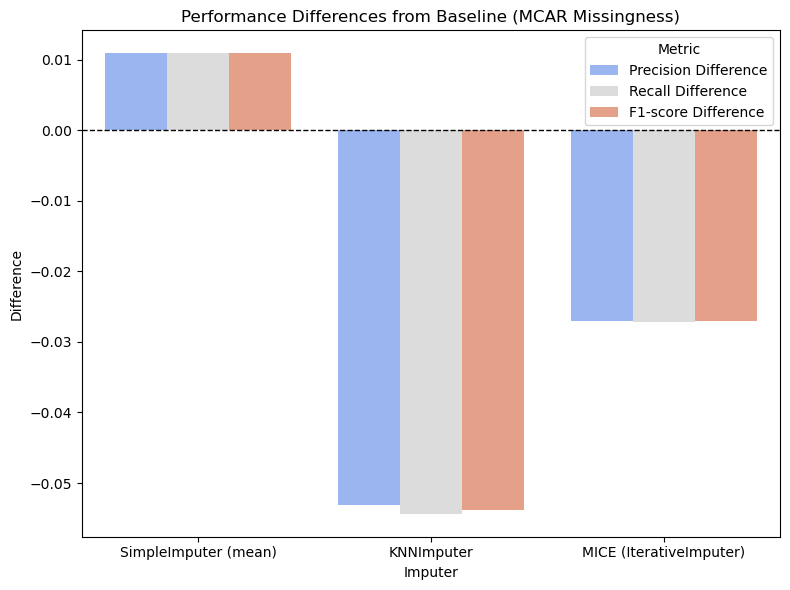

In [12]:
run_all_imputers((X_mcar_train, X_test), (y_train, y_test), "MCAR", mcar_report)

### **Main Insights**

- The `Simple Imputer` with the Mean strategy had the best performance for the MCAR dataset. That goes towards common sense, since the missing data is randomly distributed across the column, therefore choosing the mean value is a good strategy.
- The `k-NN` and `MICE` imputers had way worse performance than the Simple Imputer with the Mean strategy. This is probably because the missing data is randomly distributed across the column, so the imputers used a pattern that didn't translate well to the missing data.

## **MAR Dataset**

In [13]:
df_mar = missingness_generator(X_train, y_train, 'MAR')
X_mar_train = df_mar.drop('target', axis=1)
mar_report = run_decision_tree((X_mar_train, X_test), (y_train, y_test), None, use_imputer=False, dict_formated=True)

### **Imputation Comparison**

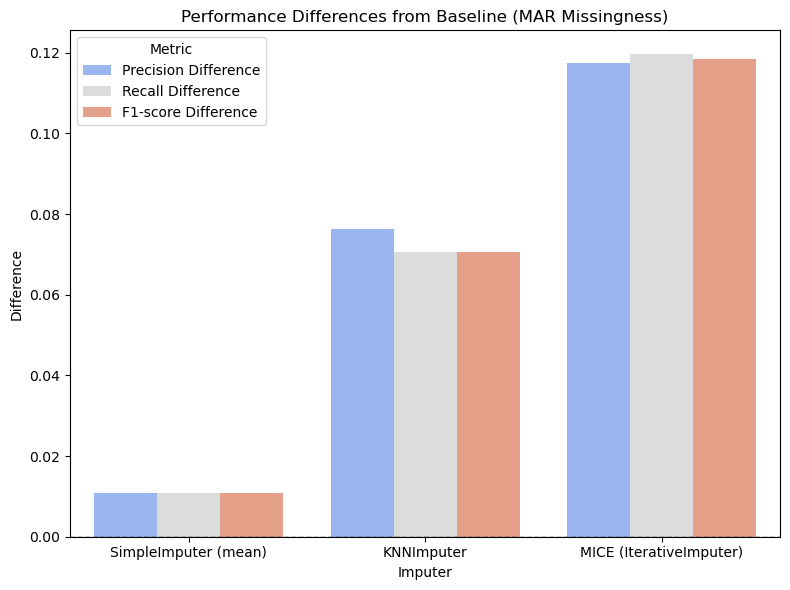

In [14]:
run_all_imputers((X_mar_train, X_test), (y_train, y_test), "MAR", mar_report)

### **Main Insights**

- The `Simple Imputer` with the Mean strategy had the worst performance for the MAR dataset. That goes towards common sense, since the missing data is related to the observed data, therefore choosing the mean value doesn't take into account the relationship between the missing data and the observed data, which can be mapped using other imputation techniques.
- The `k-NN` and `MICE` imputers had better performance than the Simple Imputer with the Mean strategy. This is probably because the missing data is related to the observed data, so the imputers used a pattern that translated well to the missing data.
- The `MICE` imputer had the best performance for the MAR dataset. This is probably because the iterative process of the MICE algorithm could better capture the relationship between the missing data and the observed data (in this case, the `Age` column).	

## **MNAR Dataset**

In [15]:
df_mnar = missingness_generator(X, y, 'MNAR')
X_mnar_train = df_mnar.drop('target', axis=1)
X_mnar_train = X_mnar_train.loc[X_train.index]
mnar_report = run_decision_tree((X_mnar_train, X_test), (y_train, y_test), None, use_imputer=False, dict_formated=True)
print(mnar_report['weighted avg'])

{'precision': 0.7875894331315356, 'recall': 0.7880434782608695, 'f1-score': 0.7876046448825278, 'support': 184.0}


### **Imputation Comparison**

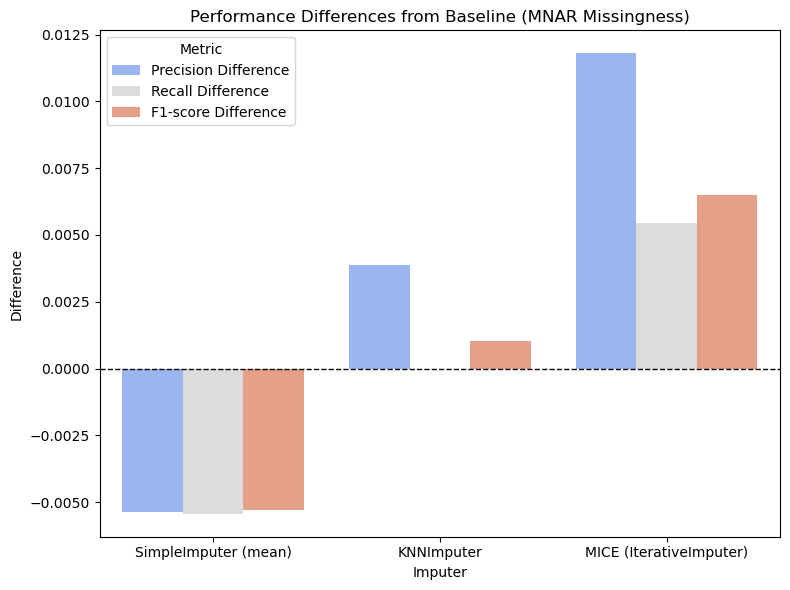

In [16]:
run_all_imputers((X_mnar_train, X_test), (y_train, y_test), "MNAR", mnar_report)

### **Main Insights**

- The `Simple Imputer` with the Mean strategy had the worst performance for the MNAR dataset. That goes towards common sense, since the missing data is related to the missing data itself, so finding a pattern in the missing data can yield better results.
- The `k-NN` and `MICE` imputers had better performance than the Simple Imputer with the Mean strategy. This is probably because the imputers used a pattern that translated well to the missing data.
- However, we must aknowledge that the discrepancy between the imputers is not as big as in the other datasets, which can be a sign that for MCAR another imputer, or just tuning the hyperparameters of the imputers could yield better results.

## **Conclusion**

In this notebook, we analyzed how the three types of missing data (MCAR, MAR and MNAR) can affect the performance of the models.

From the results, we could see that the imputation technique is very important to the performance of the model, and that the imputation technique should be chosen according to the type of missing data present in the dataset:

- For MCAR datasets, the Simple Imputer with the Mean strategy had the best performance.
- For MAR datasets, the MICE imputer had the best performance.
- For MNAR datasets, the k-NN and MICE imputer had the best performance (even though the discrepancy between the imputers is not as big as in the other datasets).